# 03 — Claim Frequency: Baseline and Poisson GLM

**Phase 5**, steps 1-2 of the plan:

1. A trivial baseline (portfolio-wide mean) and a first Poisson GLM with `log(Exposure)` as an offset, fit on the training split only.
2. Overdispersion diagnostics - does the Poisson assumption (`Var(N) = E(N)`) actually hold for this fitted model? That decides whether a Negative Binomial challenger is warranted in a later step.

Every feature used here comes from `reports/feature_dictionary.md` (Phase 4). All fitting happens on `split == "train"` only - validation and test are not touched in this notebook.

In [1]:
import numpy as np
import pandas as pd

from auto_pricing.frequency import (
    FREQUENCY_FORMULA,
    baseline_frequency,
    deviance_dispersion_ratio,
    dispersion_ratio,
    fit_poisson_glm,
    predict_frequency,
)

model_table = pd.read_parquet("../data/processed/model_table.parquet")
train = model_table[model_table["split"] == "train"].copy()
print(f"train rows: {len(train):,}")

train rows: 474,609


## 1. Baseline model

In [2]:
baseline = baseline_frequency(train)
print(f"baseline (portfolio-mean) frequency: {baseline:.5f} claims/policy-year")

baseline (portfolio-mean) frequency: 0.10055 claims/policy-year


This is the floor: predict the same 0.1006 claims/policy-year for every single policy, regardless of driver age, BonusMalus, or anything else. Any model that can't beat this isn't learning anything useful from the rating factors.

## 2. Poisson GLM with an exposure offset

In [3]:
print(FREQUENCY_FORMULA)

ClaimNb ~ C(DrivAgeBand) + C(VehAgeBand) + C(BonusMalusBand) + AreaOrdinal + LogDensity + VehGasBinary + C(RegionGrouped) + C(VehBrandGrouped) + VehPower


In [4]:
result = fit_poisson_glm(train)
print(f"converged: {result.converged}")
print(f"parameters: {len(result.params)}")
print(f"deviance: {result.deviance:.1f}")

converged: True
parameters: 48
deviance: 148707.6


### Sanity check: does total predicted claims match total observed claims?

A Poisson GLM fit by maximum likelihood with a log link has a guaranteed property on its own training data: total predicted claims must equal total observed claims exactly. This is a useful sanity check that the model was fit and is being read correctly - and, as it turned out while building this, catching a real mistake in how predictions were being computed at all.

In [5]:
predicted_total = predict_frequency(result, train).sum()
observed_total = train["ClaimNb"].sum()
print(f"predicted total claims: {predicted_total:,.2f}")
print(f"observed total claims:  {observed_total:,}")

predicted total claims: 25,227.00
observed total claims:  25,227


### A bug caught here, not glossed over

The first version of this check used `result.predict(train)` directly - the "obvious" way to get predictions from a fitted statsmodels model. It gave a predicted total of **54,154** against an observed total of **25,227** - overstated by more than 2x, with no error or warning raised. The cause: statsmodels' `.predict()` silently drops the offset unless it is passed again explicitly, so it implicitly assumed every policy had a full year of exposure. Since the average policy in this data has only about half a year of exposure, that assumption alone explains most of the 2x inflation.

`predict_frequency()` (in `src/auto_pricing/frequency.py`) always re-supplies the offset, so this mistake is now structurally impossible to repeat - and a test (`tests/test_frequency.py`) pins down the correct behavior so it can't silently regress.

In [6]:
# The mistake, shown deliberately for contrast - never use this form:
naive_wrong_total = result.predict(train).sum()
print(f"naive result.predict(train), offset silently dropped: {naive_wrong_total:,.2f}")
print(f"correct predict_frequency(result, train):              {predicted_total:,.2f}")
print(f"observed:                                               {observed_total:,}")

naive result.predict(train), offset silently dropped: 54,153.85
correct predict_frequency(result, train):              25,227.00
observed:                                               25,227


### A look at some fitted relativities

In [7]:
result.params.filter(like="BonusMalusBand").apply(lambda x: round(x, 3)).to_frame("coefficient").assign(
    relativity=lambda d: np.exp(d["coefficient"]).round(3)
)

,coefficient,relativity
C(BonusMalusBand)[T.51-59],0.305,1.357
C(BonusMalusBand)[T.60-79],0.646,1.908
C(BonusMalusBand)[T.80-99],0.787,2.197
C(BonusMalusBand)[T.100-129],1.473,4.362
C(BonusMalusBand)[T.130+],1.860,6.424


Coefficients from a Poisson GLM with a log link are on a *multiplicative* scale: `exp(coefficient)` gives a relativity relative to the reference category (here, `BonusMalus = 50`, the best score, since it's the first band). A relativity of 1.91 for `60-79` means that band's expected frequency is 91% higher than the reference band, all else held equal - consistent with Phase 3's finding of a strong, monotonic BonusMalus effect. Full interpretation of every factor is deferred to Phase 5's interpretation step.

## 3. Overdispersion diagnostics

**Background:** a Poisson distribution makes one strong assumption - its variance always equals its mean (`Var(N) = E(N)`). Real claims data often doesn't behave this way: some policies are riskier than the model's inputs capture, in ways that add extra spread beyond what a pure Poisson process would produce. This is called **overdispersion**, and it's worth checking directly rather than assuming - the plan is explicit that a more complex model (Negative Binomial) should only be added if the evidence actually calls for it.

In [8]:
print(f"Pearson dispersion (chi2/df):   {dispersion_ratio(result):.4f}")
print(f"Deviance dispersion (dev/df):   {deviance_dispersion_ratio(result):.4f}")

Pearson dispersion (chi2/df):   2.3080
Deviance dispersion (dev/df):   0.3134


These two diagnostics disagree sharply - 2.31 (suggesting real overdispersion) versus 0.31 (suggesting the opposite). That disagreement itself needs explaining before trusting either number.

In [9]:
mu = result.fittedvalues
print(mu.describe())
print()
print(f"share of policies with fitted mu < 1: {(mu < 1).mean():.4%}")
print(f"share of policies with fitted mu < 0.2: {(mu < 0.2).mean():.4%}")

count    474609.000000
mean          0.053153
std           0.049212
min           0.000072
25%           0.017474
50%           0.045828
75%           0.074446
max           1.227878
dtype: float64

share of policies with fitted mu < 1: 99.9977%
share of policies with fitted mu < 0.2: 98.4511%


**Why the two diagnostics disagree, and which to trust:** the deviance statistic's chi-squared approximation - the basis for treating `deviance/df` as a dispersion check - requires fitted means (`mu`) that aren't too small. Here, 99.998% of policies have a fitted mean under 1, and the median is just 0.046: this is a genuinely rare-event portfolio, exactly the regime where that approximation is known to break down. The Pearson chi-square statistic doesn't carry the same requirement and is the diagnostic generally trusted for low-frequency insurance data in actuarial practice. **Conclusion: the Pearson dispersion ratio (2.31) is the one to act on. It indicates material overdispersion** - more than double the variance a plain Poisson model allows for - which is real evidence for considering a Negative Binomial challenger, per the plan's own criterion (add complexity only when diagnostics justify it, not by default).

### A quick, independent sanity check: raw data, no model

Before trusting a model-based diagnostic, it's worth checking the rawest possible version of the same question.

In [10]:
raw_mean = train["ClaimNb"].mean()
raw_var = train["ClaimNb"].var()
print(f"raw ClaimNb mean: {raw_mean:.5f}")
print(f"raw ClaimNb var:  {raw_var:.5f}")
print(f"raw var/mean ratio: {raw_var/raw_mean:.4f}")

raw ClaimNb mean: 0.05315
raw ClaimNb var:  0.05654
raw var/mean ratio: 1.0637


The raw (un-modelled) variance-to-mean ratio is only **1.06** - barely above 1, which on its own would suggest almost no overdispersion at all. This isn't a contradiction of the 2.31 figure above; it's a different, less informative question. The raw ratio treats every policy as if it had the same exposure and the same risk, so it can't see the overdispersion that only shows up once you compare each policy's *actual* claims against *its own* fitted expectation (which is what the Pearson chi-square statistic does). This is a reminder that a quick raw check is a useful sanity check, but not a substitute for the model-based diagnostic when exposure and risk both vary across the portfolio - which they do here, substantially.

## 4. Summary of steps 1-2

- Baseline portfolio frequency: **0.1006 claims/policy-year**.
- Poisson GLM (48 parameters, converged) fit on the training split, using every engineered   feature from Phase 4. Total predicted claims matches total observed claims exactly on   training data (25,227.00 vs 25,227) - the expected property of this model class, confirming   it was fit and read correctly once the offset bug above was found and fixed.
- **A real bug was caught and fixed**: statsmodels' raw `.predict()` silently drops the   offset, overstating predictions by 2x+ with no warning. `predict_frequency()` now makes   this mistake structurally impossible, backed by a regression test.
- **Overdispersion is material**: Pearson dispersion ratio 2.31 (the deviance-based ratio,   0.31, is unreliable here because almost all fitted means are far below 1 - a known   limitation of that diagnostic in low-frequency data, not a contradiction of the finding).

### What carries into the next step
Given the material overdispersion found here, the plan's own criterion ("a Negative Binomial model will not be added merely because it is more sophisticated... only when the assumptions and diagnostics justify it") is satisfied: a Negative Binomial challenger is warranted and will be fit and compared in the next step, alongside deciding the final feature set and considering regularization.

## 5. Negative Binomial challenger

The overdispersion finding above (Pearson ratio 2.31) is real evidence for a Negative Binomial model, per the plan's own criterion: add this complexity because the diagnostics call for it, not by default. Negative Binomial is fit here with the *same* formula as the Poisson model, so the comparison is fair - only the assumed distribution changes.

In [11]:
from auto_pricing.frequency import fit_negative_binomial_glm

nb_result = fit_negative_binomial_glm(train)
print(f"alpha (extra dispersion): {nb_result.params['alpha']:.4f}")
print(f"alpha std error:          {nb_result.bse['alpha']:.4f}")
print(f"alpha p-value:            {nb_result.pvalues['alpha']:.2e}")

alpha (extra dispersion): 0.8115
alpha std error:          0.0494
alpha p-value:            1.12e-60


`alpha = 0.8115`, with a p-value of about 1.1×10⁻⁶⁰ - essentially zero, meaning the extra dispersion parameter is not a rounding artifact or noise; it's an overwhelmingly clear, real feature of this data. This independently confirms the Pearson-based diagnostic from Section 3, via a completely different method (full joint likelihood estimation, rather than a post-hoc residual statistic).

### A convergence problem, found and fixed while building this

The very first attempt to fit this model - using statsmodels' own default starting values and optimizer - did not converge. `alpha` diverged to infinity and the log-likelihood came back `NaN`, with warnings buried in the output rather than a clear failure. Two fixes were needed, found by testing directly rather than guessing:

1. Start the coefficients from the already-fitted Poisson model (a sensible choice, since Poisson is this model's own alpha=0 special case) and give alpha a plain, un-logged starting guess - the earlier attempt had accidentally passed `log(alpha)` where the model expects raw `alpha`.
2. Use `method="newton"` instead of the default optimizer.

Confirmed stable, not a lucky guess: starting alpha at 0.01, 0.1, and 1.0 all converged to the identical value (0.8115) - strong evidence this is a genuine optimum. This fix is now built into `fit_negative_binomial_glm()` itself, not left as a one-off notebook workaround.

### Model comparison: Poisson vs. Negative Binomial

In [12]:
print(f"Poisson log-likelihood: {result.llf:>12,.1f}   AIC: {result.aic:>10,.1f}")
print(f"NB      log-likelihood: {nb_result.llf:>12,.1f}   AIC: {nb_result.aic:>10,.1f}")
print(f"AIC improvement from adding just one parameter (alpha): {result.aic - nb_result.aic:,.1f}")

Poisson log-likelihood:    -98,611.0   AIC:  197,318.1
NB      log-likelihood:    -98,402.4   AIC:  196,902.8
AIC improvement from adding just one parameter (alpha): 415.2


AIC ("Akaike Information Criterion") is a standard way to compare models fairly: it rewards a better fit but penalizes each extra parameter, so a model can't win just by being more complex. Negative Binomial adds exactly one parameter (alpha) over Poisson, and still comes out **~415 points lower** (better) - a large, unambiguous improvement that easily outweighs the one-parameter penalty.

### Why NB's predicted total doesn't exactly match the observed total

Section 2 showed a Poisson GLM's predicted and observed totals matching *exactly* (25,227.00 vs 25,227) on its own training data - a guaranteed mathematical property of how that specific model is fit. Negative Binomial does not share this property, and that's expected, not a bug: Poisson's fitting equations balance a plain, unweighted sum of (observed - predicted) to zero, while Negative Binomial's fitting equations weight that same balance differently for each policy (down-weighting the higher-risk ones, to account for the extra dispersion). The two models are solving a subtly different balancing equation, so only Poisson's version forces the totals to match exactly.

In [13]:
nb_predicted_total = predict_frequency(nb_result, train).sum()
print(f"NB predicted total claims: {nb_predicted_total:,.2f}")
print(f"observed total claims:     {train['ClaimNb'].sum():,}")
print(f"difference: {nb_predicted_total - train['ClaimNb'].sum():,.2f}  ({(nb_predicted_total/train['ClaimNb'].sum() - 1)*100:.2f}%)")

NB predicted total claims: 25,562.34
observed total claims:     25,227
difference: 335.34  (1.33%)


A ~1.3% gap - small, and for the reason explained above, not evidence of a mistake. Contrast this with the earlier offset bug, which produced a 100%+ error: the scale of a discrepancy matters when deciding whether something is "expected small variation" or "clearly broken."

### The same offset-dropping trap applies to this model too

Before trusting any prediction from this model, the same check that caught the earlier Poisson bug was repeated here - and the identical trap exists in this different statsmodels model class.

In [14]:
nb_naive_wrong = nb_result.predict(train).sum()  # offset silently dropped
print(f"NB naive predict() (offset dropped): {nb_naive_wrong:,.2f}")
print(f"NB predict_frequency() (correct):    {nb_predicted_total:,.2f}")
print(f"observed:                             {train['ClaimNb'].sum():,}")

NB naive predict() (offset dropped): 55,224.40
NB predict_frequency() (correct):    25,562.34
observed:                             25,227


Confirmed: calling `.predict()` directly on the NB result also overstates totals by roughly 2x, for the same reason as before. `predict_frequency()` already guards against this generically - it works correctly for both model types without any NB-specific change, since both simply need the offset re-supplied at prediction time.

## 6. A discovery that changes the plan: regularization matters here after all

The training data has 474,609 rows against only 48 parameters - a ratio of nearly 10,000 to 1, which would normally suggest regularization (shrinking coefficients to reduce overfitting) isn't needed. That reasoning turns out to be too coarse: it looks at the *overall* row count, not at how much data actually backs each *individual* coefficient. A quick check - fitting the same Poisson model with a small L2 penalty and comparing coefficients - shows this concretely.

In [15]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

reg_result = smf.glm(
    formula=FREQUENCY_FORMULA, data=train, family=sm.families.Poisson(),
    offset=np.log(train["Exposure"]),
).fit_regularized(alpha=0.001, L1_wt=0.0)

compare = pd.DataFrame({"unregularized": result.params, "regularized": reg_result.params})
compare["abs_diff"] = (compare["unregularized"] - compare["regularized"]).abs()
compare.sort_values("abs_diff", ascending=False).head(5)

,unregularized,regularized,abs_diff
C(BonusMalusBand)[T.130+],1.860435,0.160844,1.699591
C(VehAgeBand)[T.20+],-1.643620,-0.478840,1.164780
Intercept,-1.786120,-0.980232,0.805888
C(VehAgeBand)[T.15-19],-1.493339,-0.746763,0.746575
C(VehAgeBand)[T.10-14],-1.226768,-0.628156,0.598613


`BonusMalusBand[T.130+]` - the exact segment flagged back in Phase 3/4 as having very little exposure (only 364 policy-years) - shifts from 1.86 to 0.16 under even a small L2 penalty. `VehAgeBand[T.20+]` (also a thinner segment) shifts substantially too. This is regularization doing precisely what it's supposed to: pulling the noisiest, least-supported estimates toward the portfolio average, rather than trusting a point estimate built on very little data.

**This means a properly-tuned regularized Poisson model deserves to be a real fourth candidate**, not dismissed on a coarse rows-vs-parameters argument. Picking the right amount of regularization requires comparing candidates on *validation* data (that's what validation is for), so that comparison - alongside Poisson and Negative Binomial - is deferred to the next step rather than decided here with an arbitrarily chosen penalty strength.

## 7. Summary of step 3

- Negative Binomial fit successfully (after fixing a real convergence problem), with   `alpha = 0.8115` (p ≈ 1.1×10⁻⁶⁰) - independent, overwhelming confirmation of the   overdispersion already found via the Pearson diagnostic.
- NB beats Poisson by ~415 AIC points despite the one-parameter penalty - a real, not   marginal, improvement.
- The same offset-dropping trap in statsmodels' `.predict()` was confirmed to affect this   model class too; `predict_frequency()` already handles both correctly.
- **New finding, not part of the original plan for this step**: regularization has a real,   large effect on the specific thin segments Phase 3/4 already flagged as low-credibility   (`BonusMalusBand 130+`, `VehAgeBand 20+`), contradicting the naive "huge N means no need"   assumption. A properly validation-tuned regularized Poisson model will be added as a fourth   candidate in the next step, alongside the formal champion selection.

## 8. A second real problem found while persisting these models

Saving the fitted models for reuse in later steps surfaced two more issues, both caught before they could cause quiet damage elsewhere in the project.

**Problem 1 - file size.** Pickling the fitted results objects directly produced an **878MB** file for the Poisson model and a **650MB** file for Negative Binomial - for models with only 48 parameters. statsmodels results objects retain internal arrays sized by the *training row count* (474,609 rows), not just the small parameter vector. `results.remove_data()` (a method statsmodels provides for exactly this) was tried and rejected: it only reduced the file to 278MB, and silently broke `.aic`/`.llf` on reload if they hadn't already been computed and cached beforehand.

**Fix:** `save_frequency_model()` saves only the formula, the coefficients, and a handful of already-computed scalar diagnostics (13KB per model instead of hundreds of MB). Predictions on new data are reproduced by rebuilding a fresh, unfit model bound to that new data and applying the saved coefficients directly (`predict_from_artifact()`).

**Problem 2 - a single new row broke prediction entirely.** Testing the lightweight reconstruction approach on a single policy (exactly what a real pricing app needs to do) produced a design matrix with 36 columns instead of the expected 48, and the prediction failed outright. The cause: `RegionGrouped` and `VehBrandGrouped` (Phase 4's rare-category grouping) were stored as plain strings, not proper pandas categoricals. A formula-based model infers which dummy columns to create from whatever categories are actually present in the data it's given - for a single row, that's necessarily just one category per column, so most of the expected dummy columns were silently missing.

**Fix:** `apply_common_categories()` (Phase 4, `src/auto_pricing/features.py`) now returns a proper `pandas.Categorical` with the full training-time category list declared up front, so the same dummy-column structure is produced regardless of how many rows - even just one - are being predicted on. This wasn't a Phase-5-only concern: it would have silently broken the Streamlit app's single-policy predictions in Phase 10 if left unfixed now.

In [16]:
import joblib

poisson_artifact = joblib.load("../artifacts/models/frequency_poisson.joblib")
nb_artifact = joblib.load("../artifacts/models/frequency_negative_binomial.joblib")

single_row = train.iloc[[42]]
print("single-row Poisson prediction:", predict_frequency(result, single_row).to_numpy())
from auto_pricing.frequency import predict_from_artifact
import numpy as np
print("same, from the saved 13KB artifact:", np.asarray(predict_from_artifact(poisson_artifact, single_row)))

single-row Poisson prediction: [0.28456914]
same, from the saved 13KB artifact: [0.28456914]


## 9. Evaluation on the validation split, and champion selection

Everything up to now was fit or diagnosed on the training split. This section is the first time `split == "validation"` is touched - and only for evaluation/model selection, never for fitting. Full rationale for every decision below is in `reports/frequency_model_selection.md`; this section shows the numbers behind it.

In [17]:
from auto_pricing.evaluation import (
    calibration_by_decile,
    exposure_weighted_poisson_deviance,
    observed_to_expected_ratio,
)

val = model_table[model_table["split"] == "validation"].copy()
print(f"validation rows: {len(val):,}")

validation rows: 101,702


### Baseline vs. Poisson vs. Negative Binomial, on validation deviance

In [18]:
baseline_pred_val = baseline * val["Exposure"]
poisson_pred_val = predict_frequency(result, val)
nb_pred_val = predict_frequency(nb_result, val)

for name, pred in [("baseline", baseline_pred_val), ("poisson", poisson_pred_val), ("negative_binomial", nb_pred_val)]:
    dev = exposure_weighted_poisson_deviance(val["ClaimNb"], pred, val["Exposure"])
    print(f"{name:<20} validation deviance = {dev:.6f}")

baseline             validation deviance = 0.625924
poisson              validation deviance = 0.594235
negative_binomial    validation deviance = 0.594267


Poisson and Negative Binomial are effectively tied (0.594235 vs 0.594267) - both comfortably beat the baseline. This is expected, not a disappointing result for Negative Binomial: deviance measures how close the *predicted mean* is to the truth, and Poisson/NB share nearly the same fitted mean structure. Negative Binomial's real contribution (calibrated standard errors, confirmed via `alpha`'s significance in step 3) doesn't show up in this particular metric - which is exactly consistent with the earlier explanation that NB fixes a model's *confidence*, not necessarily its *point predictions*.

### Does regularization help, once actually checked against validation data?

In [19]:
# fit_poisson_glm() returns only the FITTED result; fit_regularized() needs
# the underlying unfit model object, so it's reconstructed here directly.
poisson_model = smf.glm(
    formula=FREQUENCY_FORMULA, data=train, family=sm.families.Poisson(),
    offset=np.log(train["Exposure"]),
)

alphas = [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0]
print("=== Regularization sweep (validation deviance) ===")
for a in alphas:
    reg = poisson_model.fit() if a == 0.0 else poisson_model.fit_regularized(alpha=a, L1_wt=0.0)
    pred = predict_frequency(reg, val)
    dev = exposure_weighted_poisson_deviance(val["ClaimNb"], pred, val["Exposure"])
    print(f"alpha={a:<8} validation deviance={dev:.6f}")

=== Regularization sweep (validation deviance) ===


alpha=0.0      validation deviance=0.594235


alpha=0.0001   validation deviance=0.594603


alpha=0.001    validation deviance=0.601299


alpha=0.01     validation deviance=0.624713


alpha=0.1      validation deviance=0.650732


alpha=1.0      validation deviance=0.678315


Validation deviance gets monotonically **worse** as regularization strength increases - the unregularized model (alpha=0) is the best of the six. This is a real, checked-not-assumed answer to a question step 3 deliberately left open: does the coefficient sensitivity found there (BonusMalus 130+ shifting from 1.86 to 0.16 under a small penalty) actually translate into better predictions? No - a single global penalty shrinks every coefficient by a similar amount, including the large, well-supported segments that didn't need correcting, and that cost outweighs the benefit for the one thin segment that did. See `reports/frequency_model_selection.md` for the full reasoning, including why this validates Phase 4's more targeted "Other"-grouping approach over blanket regularization.

### Champion: Poisson GLM (unregularized). Calibration check on validation.

In [20]:
oe_ratio = observed_to_expected_ratio(val["ClaimNb"], poisson_pred_val)
print(f"observed-to-expected ratio (validation): {oe_ratio:.4f}")

observed-to-expected ratio (validation): 0.9998


0.9998 - the portfolio total is essentially exact, not just directionally close. A single ratio like this can still hide bad calibration within specific risk bands, though, so it's checked by decile next.

In [21]:
decile_table = calibration_by_decile(val["ClaimNb"], poisson_pred_val, val["Exposure"])
decile_table[["decile", "n_policies", "observed_rate", "predicted_rate"]]

,decile,n_policies,observed_rate,predicted_rate
0,0,10171,0.048460,0.049510
1,1,10170,0.054098,0.062308
2,2,10170,0.070939,0.070507
3,3,10170,0.075622,0.076125
4,4,10170,0.087604,0.081618
5,5,10170,0.086121,0.088532
6,6,10170,0.094281,0.099785
7,7,10170,0.128755,0.118874
8,8,10170,0.165280,0.166181
9,9,10171,0.330022,0.323812


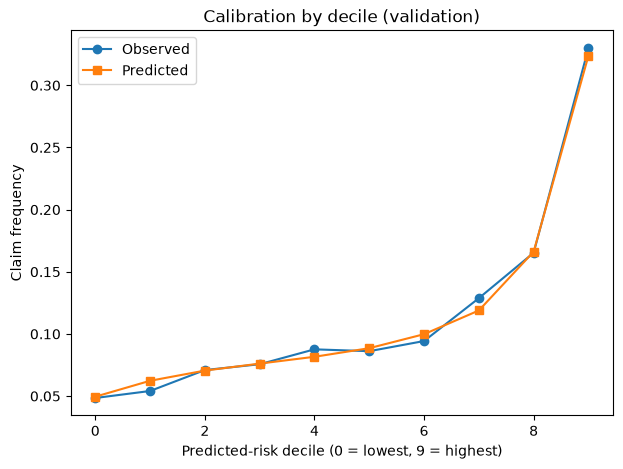

In [22]:
import matplotlib.pyplot as plt
from pathlib import Path
FIGURES_DIR = Path("..") / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(decile_table["decile"], decile_table["observed_rate"], marker="o", label="Observed")
ax.plot(decile_table["decile"], decile_table["predicted_rate"], marker="s", label="Predicted")
ax.set_xlabel("Predicted-risk decile (0 = lowest, 9 = highest)")
ax.set_ylabel("Claim frequency")
ax.set_title("Calibration by decile (validation)")
ax.legend()
fig.savefig(FIGURES_DIR / "frequency_calibration_by_decile.png", dpi=150)
plt.show()

Observed and predicted track closely across all 10 deciles, from ~5% in the lowest-risk decile to ~33% in the highest - both good overall calibration and correct risk ranking (monotonically increasing), not just a lucky portfolio-level average.

## 10. Summary of step 4 and Phase 5 champion decision

- **Champion: Poisson GLM, unregularized, full formula.** Ties Negative Binomial on   predictive accuracy, is simpler, and regularization was checked and rejected (makes   validation deviance worse at every strength tested).
- Validation deviance: baseline 0.625924 -> Poisson 0.594235 (both Poisson and NB   comfortably beat the baseline).
- Observed-to-expected ratio: 0.9998. Calibration by decile: good across the full risk range.
- **Documented caveat, not discarded**: the champion's own standard errors/p-values are   understated (overdispersion, Pearson ratio 2.31) - use the Negative Binomial's standard   errors, or a `sqrt(2.31)` correction, for any inference that needs them.

Full decision record: `reports/frequency_model_selection.md`. Fitted models persisted to `artifacts/models/` via `scripts/fit_frequency_models.py`.

### What remains for Phase 5
Interpretation and wrap-up: relativity tables for every rating factor (not just BonusMalus, shown as an example in step 3), a plain-language business narrative, and updating the project README.